## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import requests

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    Normalizer,
    PowerTransformer,
    FunctionTransformer
)

from sklearn.compose import ColumnTransformer

## Load CSV File

In [5]:
customers = pd.read_csv("customer_preprocessing_dataset.csv")

customers.head()

,Customer_ID,Name,Age,Gender,City,Income
0,CUST100000,Saira Barad,25.0,Male,Surat,174024.38
1,CUST100001,Neysa Gaba,NaN,Male,Vadodara,133758.49
2,CUST100002,Kartik Bhattacharyya,53.0,Other,Vadodara,120564.13
3,CUST100003,Miraan Doctor,69.0,Male,Delhi,80299.77
4,CUST100004,Samaira Vyas,66.0,Female,Delhi,156875.62


## Load JSON File

In [6]:
with open("transactions.json", "r") as f:
    transactions = json.load(f)

transactions = pd.DataFrame(transactions)

transactions.head()

,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


## Load SQL Database

In [7]:
conn = sqlite3.connect("preprocessing_dataset.db")

products = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)

conn.close()

products.head()

,Customer_ID,Name,Age,Gender,City,Income
0,CUST200000,Samarth Lanka,72.0,Other,Bangalore,NaN
1,CUST200001,Jivin Thakur,-1.0,Female,Mumbai,151813.51
2,CUST200002,Pari Sheth,39.0,Male,Mumbai,67666.55
3,CUST200003,Piya Balay,NaN,Other,Vadodara,147844.49
4,CUST200004,Reyansh Venkatesh,33.0,None,Vadodara,30114.90


## Load API Data

In [8]:
url = "https://dummyjson.com/users"

response = requests.get(url)

api_data = response.json()

users_api = pd.DataFrame(api_data["users"])

users_api.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


## Dataset Information

In [10]:
customers.info()

customers.describe()

customers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6309 entries, 0 to 6308
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  6309 non-null   object 
 1   Name         6309 non-null   object 
 2   Age          5658 non-null   float64
 3   Gender       6262 non-null   object 
 4   City         6267 non-null   object 
 5   Income       5657 non-null   float64
dtypes: float64(2), object(4)
memory usage: 295.9+ KB


,Customer_ID,Name,Age,Gender,City,Income
0,CUST100000,Saira Barad,25.0,Male,Surat,174024.38
1,CUST100001,Neysa Gaba,NaN,Male,Vadodara,133758.49
2,CUST100002,Kartik Bhattacharyya,53.0,Other,Vadodara,120564.13
3,CUST100003,Miraan Doctor,69.0,Male,Delhi,80299.77
4,CUST100004,Samaira Vyas,66.0,Female,Delhi,156875.62


## Merge Datasets

In [ ]:
customers["customer_id"] = range(
    101,
    101 + len(customers)
)

merged_df = customers.merge(
    transactions,
    on="customer_id",
    how="left"
)

merged_df.head()

,Customer_ID,Name,Age,Gender,City,Income,customer_id,transaction_id,product_id,amount,payment_mode,date
0,CUST100000,Saira Barad,25.0,Male,Surat,174024.38,101,T001,P001,499.0,UPI,2025-10-01
1,CUST100001,Neysa Gaba,NaN,Male,Vadodara,133758.49,102,T007,P003,1499.0,Credit Card,2025-10-09
2,CUST100002,Kartik Bhattacharyya,53.0,Other,Vadodara,120564.13,103,T002,P003,1299.0,Credit Card,2025-10-02
3,CUST100003,Miraan Doctor,69.0,Male,Delhi,80299.77,104,T003,P002,699.0,Debit Card,2025-10-03
4,CUST100004,Samaira Vyas,66.0,Female,Delhi,156875.62,105,T004,P005,1999.0,UPI,2025-10-05


## Missing Values Check

In [ ]:
merged_df.isnull().sum()

Customer_ID          0
Name                 0
Age                651
Gender              47
City                42
Income             652
customer_id          0
transaction_id    6301
product_id        6301
amount            6301
payment_mode      6301
date              6301
dtype: int64

## Histograms

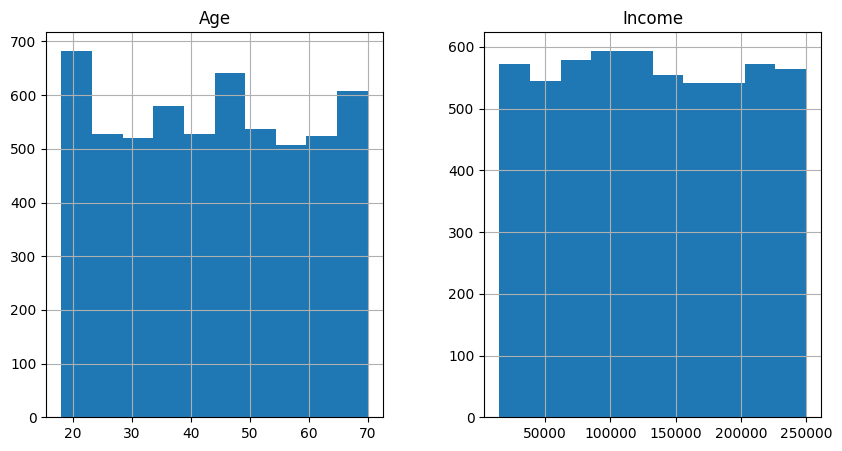

In [ ]:
merged_df[["Age", "Income"]].hist(
    figsize=(10,5)
)

plt.show()

## Boxplot

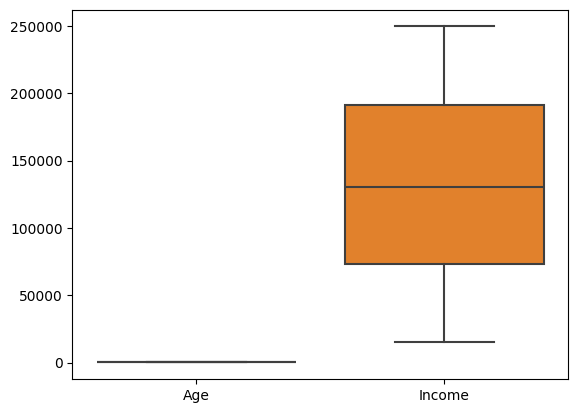

In [ ]:
sns.boxplot(
    data=merged_df[["Age", "Income"]]
)

plt.show()

##  Heatmap

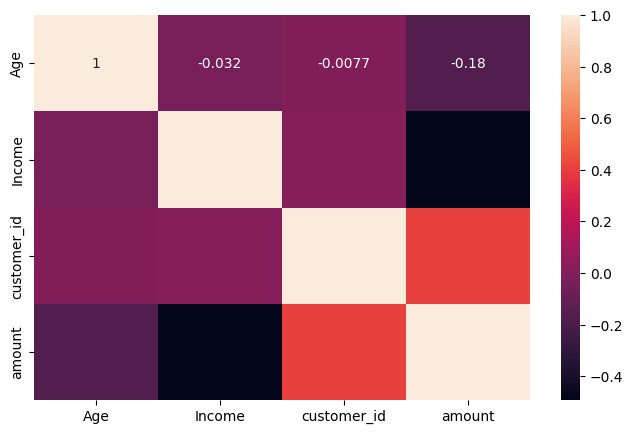

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    merged_df.select_dtypes(include=np.number).corr(),
    annot=True
)

plt.show()

## Pairplot

c:\Users\jines\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\jines\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


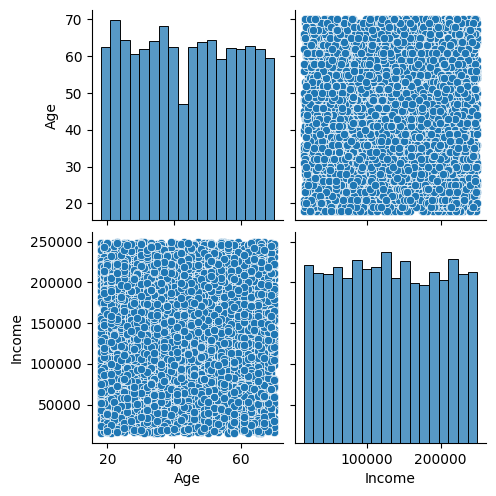

In [ ]:
sns.pairplot(
    merged_df[["Age", "Income"]]
)

plt.show()

## Simple Imputer

In [ ]:
num_imputer = SimpleImputer(strategy="mean")

merged_df["Age"] = num_imputer.fit_transform(
    merged_df[["Age"]]
)

merged_df["Income"] = num_imputer.fit_transform(
    merged_df[["Income"]]
)

## Most Frequent Imputation

In [ ]:
cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

merged_df["Gender"] = cat_imputer.fit_transform(
    merged_df[["Gender"]]
).ravel()

## Missing Indicator

In [ ]:
merged_df["Income_missing"] = merged_df[
    "Income"
].isnull().astype(int)

## Random Sample Imputation

In [ ]:
sample = merged_df["Income"].dropna().sample(
    merged_df["Income"].isnull().sum(),
    random_state=42
)

sample.index = merged_df[
    merged_df["Income"].isnull()
].index

merged_df.loc[
    merged_df["Income"].isnull(),
    "Income"
] = sample

## KNN Imputer

In [ ]:
knn = KNNImputer(n_neighbors=5)

merged_df[["Age", "Income"]] = knn.fit_transform(
    merged_df[["Age", "Income"]]
)

## MICE Imputer

In [ ]:
mice = IterativeImputer(random_state=42)

merged_df[["Age", "Income"]] = mice.fit_transform(
    merged_df[["Age", "Income"]]
)

## Z-Score Outlier Detection

In [ ]:
from scipy import stats

z = np.abs(
    stats.zscore(
        merged_df[["Age", "Income"]]
    )
)

(z > 3).sum()

Age       0
Income    0
dtype: int64

## IQR Method

In [ ]:
Q1 = merged_df["Income"].quantile(0.25)

Q3 = merged_df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

merged_df = merged_df[
    (merged_df["Income"] >= lower) &
    (merged_df["Income"] <= upper)
]

## Percentile Method

In [ ]:
lower_limit = merged_df["Income"].quantile(0.01)

upper_limit = merged_df["Income"].quantile(0.99)

merged_df["Income"] = np.clip(
    merged_df["Income"],
    lower_limit,
    upper_limit
)

## Date Features

In [ ]:
merged_df["date"] = pd.to_datetime(
    merged_df["date"]
)

merged_df["signup_date"] = pd.to_datetime(
    "2023-01-01"
)

merged_df["days_since_signup"] = (
    pd.Timestamp.today() -
    merged_df["signup_date"]
).dt.days

## Label Encoding

In [ ]:
le = LabelEncoder()

merged_df["Gender_Label"] = le.fit_transform(
    merged_df["Gender"]
)

## One Hot Encoding

In [ ]:
encoded_df = pd.get_dummies(
    merged_df,
    columns=["City"]
)

## Ordinal Encoding

In [ ]:
education = [
    "School",
    "Bachelor",
    "Master",
    "PhD"
]

merged_df["Education"] = np.random.choice(
    education,
    size=len(merged_df)
)

oe = OrdinalEncoder(
    categories=[education]
)

merged_df["Education_Encoded"] = oe.fit_transform(
    merged_df[["Education"]]
)

## StandardScaler

In [ ]:
scaler = StandardScaler()

merged_df["Income_Standard"] = scaler.fit_transform(
    merged_df[["Income"]]
)

## MinMaxScaler

In [ ]:
minmax = MinMaxScaler()

merged_df["Income_MinMax"] = minmax.fit_transform(
    merged_df[["Income"]]
)

## MaxAbsScaler

In [ ]:
maxabs = MaxAbsScaler()

merged_df["Income_MaxAbs"] = maxabs.fit_transform(
    merged_df[["Income"]]
)

## RobustScaler

In [ ]:
robust = RobustScaler()

merged_df["Income_Robust"] = robust.fit_transform(
    merged_df[["Income"]]
)

## Normalizer

In [ ]:
normalizer = Normalizer()

normalized = normalizer.fit_transform(
    merged_df[["Age", "Income"]]
)

normalized[:5]

array([[1.43658031e-04, 9.99999990e-01],
       [3.25938402e-04, 9.99999947e-01],
       [4.39600028e-04, 9.99999903e-01],
       [8.59279853e-04, 9.99999631e-01],
       [4.20715431e-04, 9.99999911e-01]])

## ColumnTransformer

In [ ]:
ct = ColumnTransformer(
    transformers=[
        (
            "standard",
            StandardScaler(),
            ["Income"]
        ),
        (
            "minmax",
            MinMaxScaler(),
            ["Age"]
        )
    ]
)

transformed = ct.fit_transform(
    merged_df
)

transformed[:5]

array([[ 0.65939382,  0.13461538],
       [ 0.03085361,  0.49225059],
       [-0.17510697,  0.67307692],
       [-0.8036233 ,  0.98076923],
       [ 0.39170608,  0.92307692]])

## Feature Engineering

In [ ]:
merged_df["purchase_per_day"] = (
    merged_df["amount"] /
    (merged_df["days_since_signup"] + 1)
)

## Log Transformation

In [ ]:
log = FunctionTransformer(np.log1p)

merged_df["Income_Log"] = log.transform(
    merged_df[["Income"]]
)

## Power Transformation

In [ ]:
pt = PowerTransformer(
    method="yeo-johnson"
)

merged_df["Income_Power"] = pt.fit_transform(
    merged_df[["Income"]]
)

## Binning

In [ ]:
merged_df["Income_Bin"] = pd.qcut(
    merged_df["Income"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

## Binarization

In [ ]:
threshold = merged_df["amount"].mean()

merged_df["frequent_buyer"] = (
    merged_df["amount"] > threshold
).astype(int)

## Export Final Dataset

In [ ]:
merged_df.to_csv(
    "processed_customer_data.csv",
    index=False
)